In [1]:
Runtime  →  Change runtime type  →  Hardware accelerator: GPU


SyntaxError: invalid character '→' (U+2192) (ipython-input-826552809.py, line 1)

In [2]:
import torch
torch.cuda.is_available(), torch.cuda.get_device_name(0)


(True, 'Tesla T4')

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
BASE = "/content/drive/MyDrive/Alzheimers/Datasets"

MRI_DATASET = f"{BASE}/MRI Dataset"
ALZ_VARIANT = f"{BASE}/ALZ_Variant Datset"


In [6]:
import pathlib

for p in pathlib.Path("/content/drive/MyDrive").glob("*Alz*"):
    print(repr(str(p)))


'/content/drive/MyDrive/Alzheimers '


In [7]:
BASE = "/content/drive/MyDrive/Alzheimers "
MRI_DATASET = f"{BASE}/Datasets/MRI Dataset"
ALZ_VARIANT = f"{BASE}/Datasets/ALZ_Variant Datset"


In [8]:
import os

print(os.listdir(BASE))
print(os.listdir(f"{BASE}/Datasets"))
print(os.listdir(MRI_DATASET))


['Datasets', 'models', 'outputs']
['ALZ_Variant Datset', 'MRI Dataset']
['Kaggle MRI Alzheimers', 'train.parquet', 'test.parquet', 'class_mapping.json']


In [9]:
import os
from PIL import Image
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


In [10]:
import pandas as pd

BASE = "/content/drive/MyDrive/Alzheimers "
DATA = f"{BASE}/Datasets/MRI Dataset"

train_df = pd.read_parquet(f"{DATA}/train.parquet")
test_df  = pd.read_parquet(f"{DATA}/test.parquet")

train_df.head(), train_df.shape, test_df.shape



(                                               image  label
 0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      2
 1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
 2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
 3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
 4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      2,
 (5120, 2),
 (1280, 2))

In [11]:
import io
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


In [12]:
IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [13]:
class MRIDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # 1️⃣ read bytes
        img_bytes = row["image"]["bytes"]

        # 2️⃣ convert bytes → PIL image
        img = Image.open(io.BytesIO(img_bytes)).convert("RGB")

        # 3️⃣ get label (already an int)
        label = int(row["label"])

        # 4️⃣ apply transforms
        if self.transform:
            img = self.transform(img)

        return img, label


In [14]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df["label"],
    random_state=42
)


In [15]:
train_ds = MRIDataset(train_df, train_tfms)
val_ds   = MRIDataset(val_df,   test_tfms)
test_ds  = MRIDataset(test_df,  test_tfms)


In [16]:
BATCH_SIZE = 16

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)


In [17]:
imgs, labels = next(iter(train_loader))
imgs.shape, labels[:10]


(torch.Size([16, 3, 224, 224]), tensor([2, 2, 2, 3, 3, 3, 2, 0, 2, 3]))

In [18]:
import json

mapping_path = "/content/drive/MyDrive/Alzheimers /Datasets/MRI Dataset/class_mapping.json"

idx_to_class = {
    0: "Non-Demented",
    1: "Very Mild Demented",
    2: "Mild Demented",
    3: "Moderate Demented"
}

with open(mapping_path, "w") as f:
    json.dump(idx_to_class, f)

idx_to_class


{0: 'Non-Demented',
 1: 'Very Mild Demented',
 2: 'Mild Demented',
 3: 'Moderate Demented'}

In [19]:
import torch
import torch.nn as nn
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

In [21]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# freeze backbone
for param in model.parameters():
    param.requires_grad = False

# replace classifier head (4 classes)
model.fc = nn.Linear(model.fc.in_features, 4)

model = model.to(device)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 234MB/s]


In [22]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),   # only train head
    lr=1e-3
)


In [23]:
import os

MODELS = "/content/drive/MyDrive/Alzheimers /models"
os.makedirs(MODELS, exist_ok=True)


In [24]:
from tqdm import tqdm

EPOCHS = 8
best_val_acc = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):

    # ---------- TRAIN ----------
    model.train()
    correct = total = running_loss = 0

    for x,y in tqdm(train_loader):
        x,y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # ---------- VALIDATE ----------
    model.eval()
    correct = total = running_loss = 0

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out,y)

            running_loss += loss.item() * x.size(0)
            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    val_loss = running_loss / total
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Acc {train_acc:.3f} Loss {train_loss:.3f} | "
          f"Val Acc {val_acc:.3f} Loss {val_loss:.3f}")

    # ---------- SAVE BEST MODEL ----------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{MODELS}/best_model.pt")
        print("⭐ Saved new best model")


100%|██████████| 272/272 [00:23<00:00, 11.55it/s]


Epoch 1/8 | Train Acc 0.536 Loss 0.988 | Val Acc 0.560 Loss 0.940
⭐ Saved new best model


100%|██████████| 272/272 [00:22<00:00, 11.84it/s]


Epoch 2/8 | Train Acc 0.565 Loss 0.929 | Val Acc 0.583 Loss 0.908
⭐ Saved new best model


100%|██████████| 272/272 [00:22<00:00, 11.99it/s]


...

Epoch 6/8 | Train Acc 0.591 Loss 0.878 | Val Acc 0.602 Loss 0.851


100%|██████████| 272/272 [00:22<00:00, 12.00it/s]


Epoch 7/8 | Train Acc 0.592 Loss 0.872 | Val Acc 0.591 Loss 0.864


100%|██████████| 272/272 [00:22<00:00, 11.96it/s]


Epoch 8/8 | Train Acc 0.605 Loss 0.862 | Val Acc 0.587 Loss 0.872


In [25]:
train_accs, val_accs


([0.5356158088235294,
  0.5650275735294118,
  0.5723805147058824,
  0.5776654411764706,
  0.5799632352941176,
  0.5914522058823529,
  0.5921415441176471,
  0.6045496323529411],
 [0.5598958333333334,
  0.5833333333333334,
  0.5963541666666666,
  0.5989583333333334,
  0.6080729166666666,
  0.6015625,
  0.5911458333333334,
  0.5872395833333334])

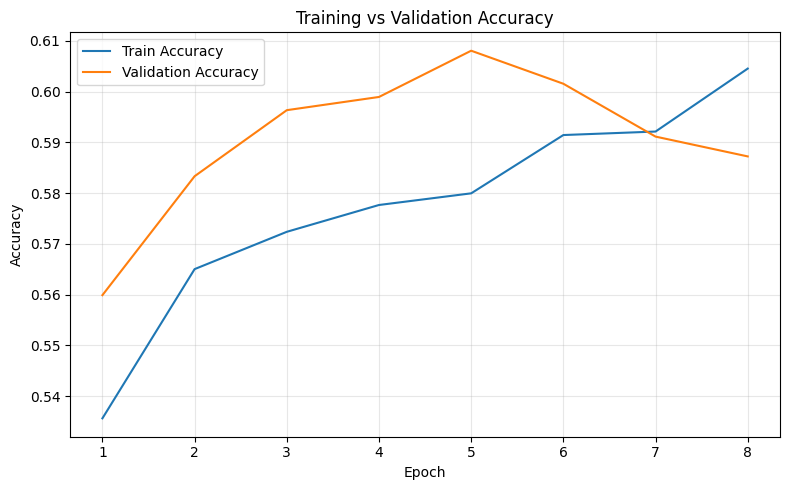

In [26]:
import matplotlib.pyplot as plt
import os

BASE = "/content/drive/MyDrive/Alzheimers "
OUTPUTS = f"{BASE}/outputs"
os.makedirs(OUTPUTS, exist_ok=True)

epochs = range(1, len(train_accs)+1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f"{OUTPUTS}/accuracy_curve.png", dpi=200)
plt.show()


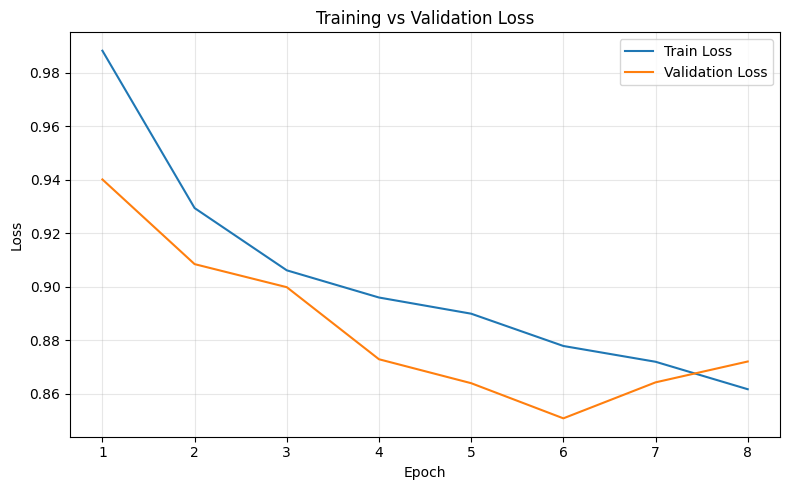

In [27]:
import matplotlib.pyplot as plt
import os

BASE = "/content/drive/MyDrive/Alzheimers "
OUTPUTS = f"{BASE}/outputs"
os.makedirs(OUTPUTS, exist_ok=True)

epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f"{OUTPUTS}/loss_curve.png", dpi=200)
plt.show()


In [28]:
import torch
import numpy as np
import torchvision.transforms as transforms

wrong = []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        out = model(x)
        preds = out.argmax(1)

        for img, true, pred in zip(x, y, preds):
            if true != pred and len(wrong) < 10:   # collect first 10 mistakes
                wrong.append((img.cpu(), int(true.cpu()), int(pred.cpu())))

        if len(wrong) >= 10:
            break

len(wrong)


10

In [30]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]


In [31]:
inv_norm = transforms.Normalize(
    mean=[-m/s for m, s in zip([0.485, 0.456, 0.406],
                               [0.229, 0.224, 0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]]
)


In [33]:
class_names = [
    "Non-Demented",
    "Very Mild Demented",
    "Mild Demented",
    "Moderate Demented"
]


In [34]:
import json

with open("/content/drive/MyDrive/Alzheimers /Datasets/MRI Dataset/class_mapping.json") as f:
    idx_to_class = json.load(f)

class_names = [idx_to_class[str(i)] for i in range(len(idx_to_class))]
class_names


['Non-Demented', 'Very Mild Demented', 'Mild Demented', 'Moderate Demented']

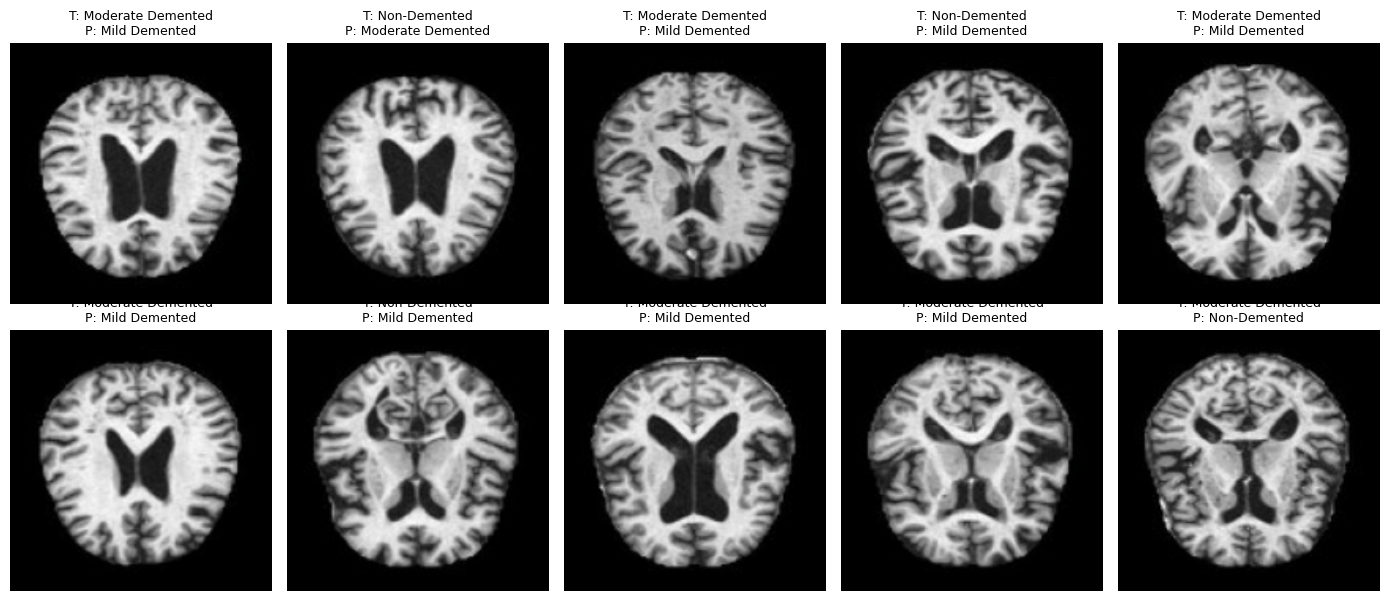

In [36]:
import matplotlib.pyplot as plt
import os

BASE = "/content/drive/MyDrive/Alzheimers "
OUTPUTS = f"{BASE}/outputs"
os.makedirs(OUTPUTS, exist_ok=True)

plt.figure(figsize=(14, 6))

for i, (img, true, pred) in enumerate(wrong):
    plt.subplot(2, 5, i + 1)

    # denormalize
    img = inv_norm(img).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(f"T: {class_names[true]}\nP: {class_names[pred]}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.savefig(f"{OUTPUTS}/misclassified.png", dpi=220)
plt.show()


In [37]:
import os

BASE = "/content/drive/MyDrive/Alzheimers "
GRADCAM_DIR = f"{BASE}/outputs/gradcam"
os.makedirs(GRADCAM_DIR, exist_ok=True)
GRADCAM_DIR


'/content/drive/MyDrive/Alzheimers /outputs/gradcam'